In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
fastf1.Cache.enable_cache('../cache')
sns.set_style('whitegrid')
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# We'll use 2025 Monaco Grand Prix

# Load qualifying session
quali = fastf1.get_session(2025, 'Monaco', 'Q')
quali.load()

# Load practice sessions
fp1 = fastf1.get_session(2025, 'Monaco', 'FP1')
fp1.load()

fp2 = fastf1.get_session(2025, 'Monaco', 'FP2')
fp2.load()

fp3 = fastf1.get_session(2025, 'Monaco', 'FP3')
fp3.load()

print(f"✅ Loaded Monaco 2025 sessions")
print(f"   - Qualifying: {len(quali.laps)} laps")
print(f"   - FP1: {len(fp1.laps)} laps")
print(f"   - FP2: {len(fp2.laps)} laps")
print(f"   - FP3: {len(fp3.laps)} laps")

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '81', '44', '1', '6', '14', '31', '30', '23', '55', '22', '27', '63', '12', '5', '87', '10', '18', '43']
core           INFO 	Loading data for Monaco Grand Prix - Practice 1 [v3.8.1]
req            INFO 	Using cache

✅ Loaded Monaco 2025 sessions
   - Qualifying: 433 laps
   - FP1: 610 laps
   - FP2: 612 laps
   - FP3: 485 laps


In [3]:
# Cell 3: Explore the qualifying data
# Let's see what columns/data we have

print("Qualifying Data Preview:")
print(quali.laps.head())
print("\n" + "="*80 + "\n")

print(" Available Columns:")
print(quali.laps.columns.tolist())
print("\n" + "="*80 + "\n")

print(" Drivers in Qualifying:")
print(quali.laps['Driver'].unique())

Qualifying Data Preview:
                    Time Driver DriverNumber                LapTime  \
0 0 days 00:20:18.989000    NOR            4 0 days 00:01:47.078000   
1 0 days 00:21:31.849000    NOR            4 0 days 00:01:12.860000   
2 0 days 00:23:11.019000    NOR            4 0 days 00:01:39.170000   
3 0 days 00:24:22.615000    NOR            4 0 days 00:01:11.596000   
4 0 days 00:25:56.516000    NOR            4 0 days 00:01:33.901000   

   LapNumber  Stint             PitOutTime PitInTime            Sector1Time  \
0        1.0    1.0 0 days 00:18:32.730000       NaT 0 days 00:00:26.421000   
1        2.0    1.0                    NaT       NaT 0 days 00:00:19.256000   
2        3.0    1.0                    NaT       NaT 0 days 00:00:25.163000   
3        4.0    1.0                    NaT       NaT 0 days 00:00:18.806000   
4        5.0    1.0                    NaT       NaT 0 days 00:00:25.155000   

             Sector2Time  ... FreshTyre     Team           LapStartTime  

In [4]:
# Goal: Use practice times to predict qualifying position

# Get best lap time from each session for each driver
def get_best_laps(session):
    """
    Extracts best lap time for each driver from a session
    Returns: DataFrame with Driver and BestTime columns
    """
    # Get all valid laps (exclude pit laps and invalid times)
    valid_laps = session.laps[session.laps['LapTime'].notna()]
    valid_laps = valid_laps[valid_laps['PitOutTime'].isna()]
    
    # Group by driver and get minimum lap time
    best_times = valid_laps.groupby('Driver')['LapTime'].min().reset_index()
    
    # Convert timedelta to seconds for easier math
    best_times['BestTimeSeconds'] = best_times['LapTime'].dt.total_seconds()
    
    return best_times[['Driver', 'BestTimeSeconds']]

# Extract best times from each session
fp1_best = get_best_laps(fp1)
fp1_best.columns = ['Driver', 'FP1_BestTime']

fp2_best = get_best_laps(fp2)
fp2_best.columns = ['Driver', 'FP2_BestTime']

fp3_best = get_best_laps(fp3)
fp3_best.columns = ['Driver', 'FP3_BestTime']

# Get qualifying results (our target variable - what we want to predict)
quali_results = quali.laps.groupby('Driver')['LapTime'].min().reset_index()
quali_results['QualiTimeSeconds'] = quali_results['LapTime'].dt.total_seconds()

# Sort by qualifying time to get positions
quali_results = quali_results.sort_values('QualiTimeSeconds').reset_index(drop=True)
quali_results['Position'] = range(1, len(quali_results) + 1)
quali_results = quali_results[['Driver', 'Position']]

# Merge all data together
ml_dataset = quali_results.merge(fp1_best, on='Driver', how='left')
ml_dataset = ml_dataset.merge(fp2_best, on='Driver', how='left')
ml_dataset = ml_dataset.merge(fp3_best, on='Driver', how='left')

# Remove any drivers with missing practice data
ml_dataset = ml_dataset.dropna()

print("ML Dataset Created!")
print(f"   Drivers: {len(ml_dataset)}")
print(f"   Features: FP1, FP2, FP3 best times")
print(f"   Target: Qualifying Position\n")
print(ml_dataset.head(10))

ML Dataset Created!
   Drivers: 20
   Features: FP1, FP2, FP3 best times
   Target: Qualifying Position

  Driver  Position  FP1_BestTime  FP2_BestTime  FP3_BestTime
0    NOR         1        72.290        71.677        71.247
1    LEC         2        71.964        71.355        70.953
2    PIA         3        72.342        71.393        71.398
3    HAM         4        72.690        71.460        71.516
4    VER         5        72.127        72.068        71.233
5    ALB         6        72.314        71.918        71.668
6    HAD         7        73.187        71.842        72.271
7    ALO         8        72.727        71.890        72.101
8    OCO         9        73.394        72.541        72.499
9    LAW        10        73.429        71.823        71.814


In [5]:
# Prepare data for modeling
X = ml_dataset[['FP1_BestTime', 'FP2_BestTime', 'FP3_BestTime']]    
y = ml_dataset['Position']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#create and train model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)

print("Model Trained!")
print(f"\n Model Performance:")
print(f"   MAE (Mean Absolute Error): {mae:.2f} positions")
print(f"   RMSE (Root Mean Squared Error): {rmse:.2f} positions")
print(f"   R² Score: {r2_score:.3f}")
print(f"\n Interpretation:")
print(f"   On average, predictions are off by {mae:.2f} positions")
if r2_score > 0.7:
    print(f"   Model explains {r2_score*100:.1f}% of variance (GOOD!)")
elif r2_score > 0.5:
    print(f"   Model explains {r2_score*100:.1f}% of variance (DECENT)")
else:
    print(f"   Model explains {r2_score*100:.1f}% of variance (NEEDS IMPROVEMENT)")

Model Trained!

 Model Performance:
   MAE (Mean Absolute Error): 3.16 positions
   RMSE (Root Mean Squared Error): 14.59 positions
   R² Score: 0.760

 Interpretation:
   On average, predictions are off by 3.16 positions
   Model explains 76.0% of variance (GOOD!)


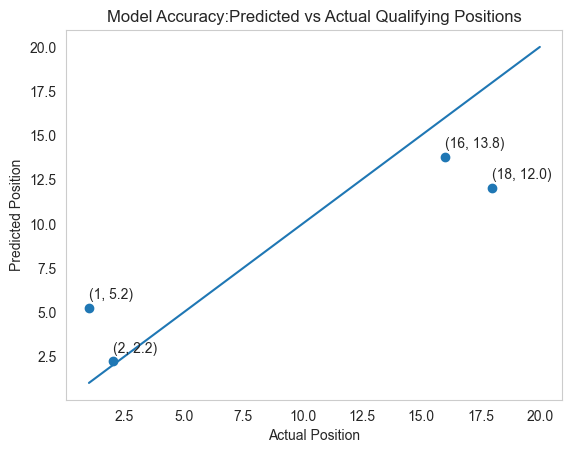

In [14]:
plt.scatter(x=y_test, y=y_pred)
plt.plot([1,20], [1,20])

for i in range(len(y_test)):
    actual = y_test.values[i]
    predicted = y_pred[i]
    plt.text(actual, predicted + 0.5, f"({actual}, {predicted:.1f})")

plt.xlabel("Actual Position")
plt.ylabel("Predicted Position")
plt.title("Model Accuracy:Predicted vs Actual Qualifying Positions")
plt.grid()
plt.show()





# Analysis

In this project, I explored Formula 1 by predicting qualifying positions based on driver lap times from three free practice sessions. I used the FastF1 database and focused on the Monaco 2025 race weekend. I extracted lap times from FP1, FP2, and FP3, along with actual qualifying positions, and fed this data into a machine learning model. The model learned patterns from the practice sessions to predict qualifying positions.

## Results

The model achieved the following performance metrics:
- **MAE (Mean Absolute Error)**: 3.16 positions
- **RMSE (Root Mean Squared Error)**: [14.59]
- **R² Score**: 0.76 (76%)

This means the model, on average, predicted positions within approximately 3 positions of the actual result and explained 76% of the variance in qualifying positions. Given that the model only used practice session times and didn't account for thousands of external factors (weather changes, tire strategies, driver errors, mechanical issues), I consider this strong performance for a simple linear regression model.

## Key Findings

Looking at the scatter plot, the model struggled most with mid-field positions (around P12-P19). These positions are occupied by teams that aren't consistently fast or slow, making them harder to predict. One particularly large error shows the model predicting P12 when the actual position was P18 - a 6-position difference that's nearly twice the MAE. This single prediction significantly skewed the average error.

In contrast, the model performed much better for front-runners (P1-P5). The top teams have more consistent performance, making their qualifying positions more predictable. The plot shows predictions of (1, 5.2) and (2, 2.2) - with the second being nearly perfect with only a 0.2 position difference.

## What I Learned

This project taught me how to:
- Build an end-to-end machine learning pipeline
- Load and process real-world data from an API (FastF1)
- Engineer features from raw data (extracting best lap times)
- Split data into training and testing sets to properly evaluate models
- Apply linear regression to a real problem
- Evaluate model performance using multiple metrics (MAE, RMSE, R²)
- Visualize predictions vs actual results using scatter plots

I particularly enjoyed applying concepts from class such as train/test splitting and linear regression to a real Formula 1 dataset. This hands-on experience solidified my understanding of the machine learning workflow.

## Potential Improvements

To improve this model's accuracy, I could:
- Include more features (weather data, tire compounds, track temperature, driver skill ratings)
- Train on multiple race weekends instead of just Monaco
- Try more advanced algorithms (Random Forest, XGBoost, Neural Networks)
- Add driver-specific features (historical performance, experience level)
- Account for track-specific characteristics (Monaco is unique with tight corners)
- Include team performance trends throughout the season. 